In [1]:
import pandas as pd
import numpy as np

churn_ds = pd.read_csv('C:/Users/chris/Desktop/model optimization/WA_Fn-UseC_-Telco-Customer-Churn.csv', delimiter=',')
churn_ds.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
#TotalCharges has an empty space value, thus it will be removed
churn_ds['TotalCharges'] = churn_ds['TotalCharges'].replace(' ', np.nan)
churn_ds.dropna(subset=['TotalCharges'], inplace=True)

# dummy encoding of churn:
churn_ds = pd.get_dummies(churn_ds, columns=['Churn'], drop_first=True)

In [3]:
n_counts = churn_ds['Churn_Yes'].value_counts()
# list of all categorical columns
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

#calculating WOE and IV for each categorical column with function
def woe_and_iv(ds,categorical_column,target):
    lst = []
    for value in ds[categorical_column].unique():
        lst.append(
            {
                'value':value,
                'all': len(ds[ds[categorical_column]==value]),
                'good': len(ds[(ds[categorical_column]== value)&(ds[target]==0)]),
                'bad': len(ds[(ds[categorical_column]== value)&(ds[target]==1)])
            }
        )
    d = pd.DataFrame(lst)
    d['distinct_good'] = d['good']/d['good'].sum()
    d['distinct_bad'] = d['bad']/d['bad'].sum()

    # WOE & IV for distinct category of column calculation
    d['woe'] = np.log(d['distinct_good']/d['distinct_bad'])
    d['iv'] = (d['distinct_good'] - d['distinct_bad']) * d['woe']

    final_iv_score = d['iv'].sum()

    return final_iv_score, d

for column in categorical_columns:
    iv, woe_table = woe_and_iv(churn_ds, column, 'Churn_Yes')
    print(f'Column named {column} :')
    print(f'-> sum of ivs of all categories of that column: {iv}')
# from above calculation, the columns with an IV above 0.02 will be kept

Column named gender :
-> sum of ivs of all categories of that column: 0.0003741275473717624
Column named SeniorCitizen :
-> sum of ivs of all categories of that column: 0.10508415840100006
Column named Partner :
-> sum of ivs of all categories of that column: 0.11787718545921688
Column named Dependents :
-> sum of ivs of all categories of that column: 0.15316862485551963
Column named PhoneService :
-> sum of ivs of all categories of that column: 0.000712901111018082
Column named MultipleLines :
-> sum of ivs of all categories of that column: 0.008168889704858528
Column named InternetService :
-> sum of ivs of all categories of that column: 0.6152530433805836
Column named OnlineSecurity :
-> sum of ivs of all categories of that column: 0.7152919041116934
Column named OnlineBackup :
-> sum of ivs of all categories of that column: 0.5264879357992501
Column named DeviceProtection :
-> sum of ivs of all categories of that column: 0.4976098551845487
Column named TechSupport :
-> sum of ivs o

In [4]:
# the values that will be droped:
# 'gender', 'PhoneService', 'MultipleLines'
churn_ds_copy = churn_ds
churn_ds = churn_ds.drop(['customerID','gender', 'PhoneService', 'MultipleLines'],axis=1)

#one-hot  encoding  to all categorical columns
churn_enc = pd.get_dummies(churn_ds, columns=[
    'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
] )

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# convinient funciton to test a model
def test_model(model_used, x_t, y_t, title = 'Model Tested'):
    y_prob = model_used.predict(x_t)
    y_p = []
    for value in y_prob:
        if value > 0.5: y_p.append(1) #if predicted something True, which should be a probability higher or equal to 50
        else:y_p.append(0) # if not, which means False
    acc = accuracy_score(y_t, y_p)
    print(title)
    print('Accuracy:', acc)
    print("                        Classification Report \n",classification_report(y_t, y_p))
    print("Confusion Matrix: \n",confusion_matrix(y_test, y_p))
    print("="*60)

    # Sensitivity (recall of True cases - churn = Yes), Specificity (recall of False cases - churn = No) ,Precision, type I error (false positives) and type II error (false negatives) are shown in the classification report

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


numerical_columns = ['tenure','MonthlyCharges','TotalCharges']

#features. all values but churn (y) and customerid which is irrelevant
x = churn_enc.drop(['Churn_Yes'],axis=1)

#target value
y = churn_enc['Churn_Yes']

#split data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
# print (x_test)
# normalization with scaler
scaler = StandardScaler()
x_train [numerical_columns] = scaler.fit_transform(x_train[numerical_columns])
x_test [numerical_columns] = scaler.transform(x_test[numerical_columns])

# print(x_train)

model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)

test_model(model,x_test,y_test,'Logistic Regression')

Logistic Regression
Accuracy: 0.7889125799573561
                        Classification Report 
               precision    recall  f1-score   support

       False       0.84      0.88      0.86      1033
        True       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix: 
 [[911 122]
 [175 199]]


In [9]:
#testing random forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300, # amount of "trees" during training
    min_samples_split=2, #minimum number of samples required to successfully split an internal node in any given tree
    min_samples_leaf=1, #minimum number of samples that must be present at a leaf node after a split has occurred
    max_features='sqrt', #limits the number of features considered when looking for the best split at each decision tree node based on the squared root of the features
    bootstrap=True,
    random_state=42
)

random_forest_model.fit(x_train, y_train)

test_model(random_forest_model, x_test, y_test,'Random Forest model test results.')

Random Forest model test results.
Accuracy: 0.7796730632551528
                        Classification Report 
               precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix: 
 [[916 117]
 [193 181]]


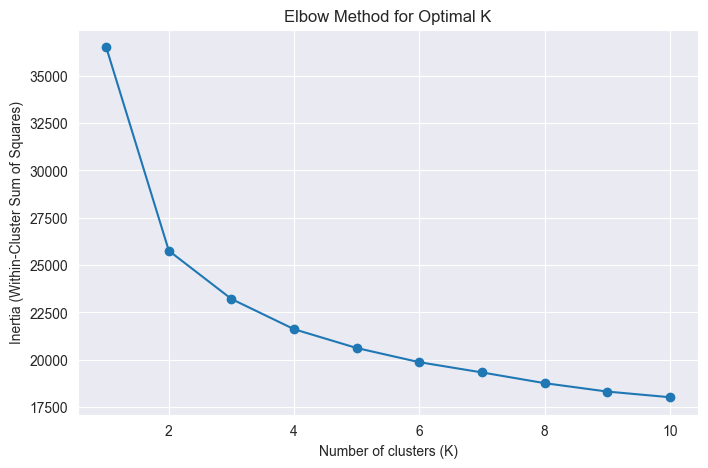

In [10]:
#preparing for K-means, firstly with PCA  and then without it
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def elbow_method(data):
    inertia = []
    K_range = range(1, 11)  # test k from 1 to 10

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inertia, marker='o')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
    plt.grid(True)
    plt.show()

#finding out groups for all categorical and demographic data, so all the categorical data in the dataset

x = pd.get_dummies(churn_ds_copy[categorical_columns], drop_first=True)
scaled_x = scaler.fit_transform(x)
elbow_method(x)

Components for 90% variance: 14


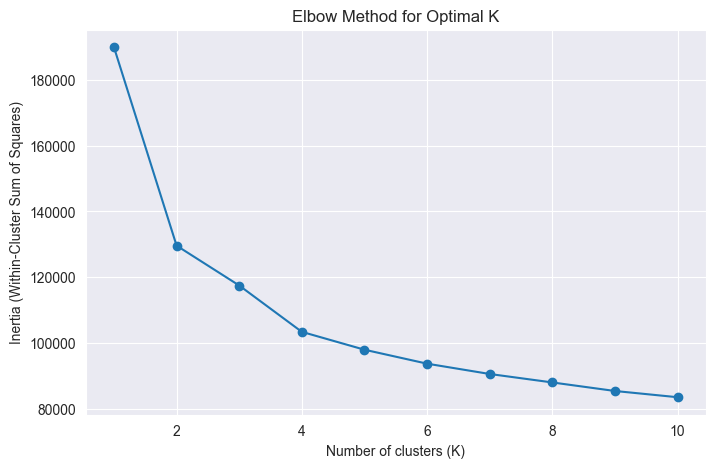

In [11]:
pca = PCA()
pca.fit(scaled_x)

# gathering the components with 90% variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.90) + 1
print(f"Components for 90% variance: {d}")

pca_90 = PCA(n_components=d)
x_pca = pca.fit_transform(scaled_x)

elbow_method(x_pca)

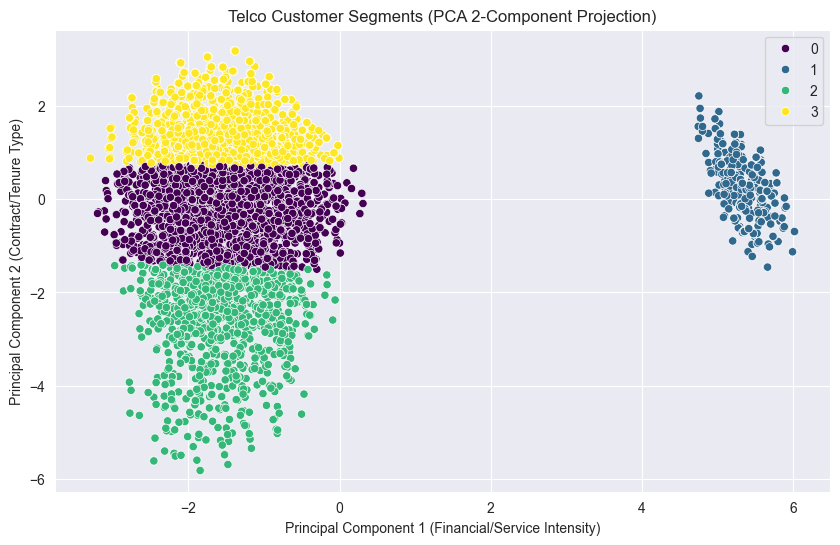

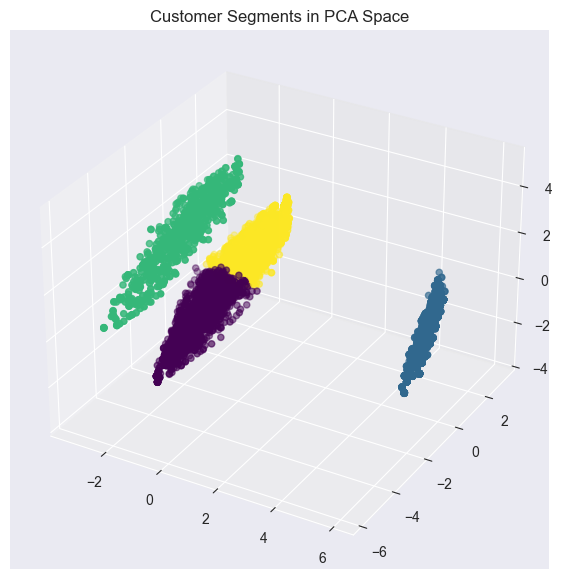

In [12]:
import seaborn as sb
# Reduce to 2 for visualization
pca_2 = PCA(n_components=2)
x_vis = pca_2.fit_transform(scaled_x)

# Fit K-means with 4 Ks, which was concluded from above graphs
kmeans_final = KMeans(n_clusters=4, random_state=42)
labels = kmeans_final.fit_predict(x_vis)

# Scatterplot
plt.figure(figsize=(10,6))
sb.scatterplot(x=x_vis[:,0], y=x_vis[:,1], hue=labels, palette='viridis')
plt.title("Telco Customer Segments (PCA 2-Component Projection)")
plt.xlabel("Principal Component 1 (Financial/Service Intensity)")
plt.ylabel("Principal Component 2 (Contract/Tenure Type)")
plt.show()


# Apply PCA with the chosen number of components (e.g., 3 for visualization)
pca_3 = PCA(n_components=3)
x_pca_3 = pca_3.fit_transform(scaled_x)

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
churn_ds['Cluster'] = kmeans.fit_predict(x_pca_3)

# Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x_pca_3[:, 0], x_pca_3[:, 1], x_pca_3[:, 2], c=churn_ds['Cluster'], cmap='viridis')
plt.title("Customer Segments in PCA Space")
plt.show()

Churn_Yes     False     True 
Cluster                      
0          0.868740  0.131260
1          0.925658  0.074342
2          0.750000  0.250000
3          0.544463  0.455537


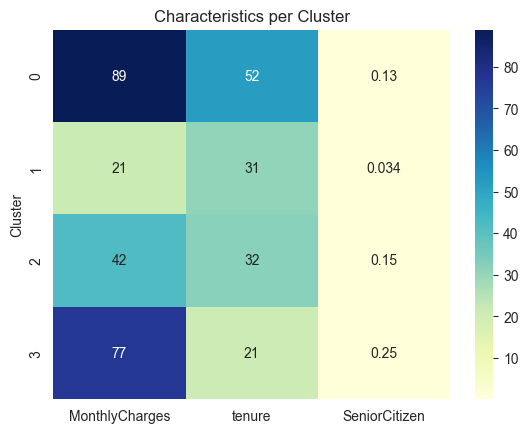

In [13]:
# Analysis of churn by cluster
churn_analysis = churn_ds.groupby('Cluster')['Churn_Yes'].value_counts(normalize=True).unstack()
print(churn_analysis)

# Visualizing segment characteristics
cluster_features = churn_ds.groupby('Cluster')[['MonthlyCharges', 'tenure', 'SeniorCitizen']].mean()
sb.heatmap(cluster_features, annot=True, cmap='YlGnBu')
plt.title("Characteristics per Cluster")
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
#prompt creation based on below columns:
# ['gender', 'SeniorCitizen', 'Partner', 'Dependents','InternetService', 'Contract', 'PaymentMethod']
#to reset index from data cleansing
churn_ds_copy = churn_ds_copy.reset_index(drop=True)

def create_prompt(row):
    return (f"gender {row['gender']} senior {row['SeniorCitizen']} "
            f"partner {row['Partner']} dependents {row['Dependents']} "
            f"internet {row['InternetService']} contract {row['Contract']} "
            f"payment {row['PaymentMethod']}")

churn_ds_copy['prompt'] = churn_ds_copy.apply(create_prompt,axis=1)

print(churn_ds_copy['prompt'][0])

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer() # 100 features is plenty for these combinations

# Fit and transform the prompt column
x_tfidf = tfidf.fit_transform(churn_ds_copy['prompt']).toarray()

# Convert to a DataFrame to see the "word" columns
tfidf_df = pd.DataFrame(x_tfidf, columns=tfidf.get_feature_names_out())

print(tfidf_df.head())

gender Female senior 0 partner Yes dependents No internet DSL contract Month-to-month payment Electronic check
   automatic      bank  card     check  contract  credit  dependents  \
0    0.00000  0.000000   0.0  0.255620  0.162624     0.0    0.162624   
1    0.00000  0.000000   0.0  0.254315  0.161794     0.0    0.161794   
2    0.00000  0.000000   0.0  0.245120  0.155944     0.0    0.155944   
3    0.27109  0.372661   0.0  0.000000  0.148065     0.0    0.148065   
4    0.00000  0.000000   0.0  0.243233  0.154743     0.0    0.154743   

        dsl  electronic    female  ...       one     optic   partner  \
0  0.336320    0.339788  0.276856  ...  0.000000  0.000000  0.162624   
1  0.334604    0.000000  0.000000  ...  0.414728  0.000000  0.161794   
2  0.322505    0.000000  0.000000  ...  0.000000  0.000000  0.155944   
3  0.306210    0.000000  0.000000  ...  0.379536  0.000000  0.148065   
4  0.000000    0.323323  0.263440  ...  0.000000  0.281661  0.154743   

    payment    senior  

In [15]:
# training a new logistic regression and random forest model from scratch
x_numeric_plus_tfidf = churn_ds_copy[['tenure','MonthlyCharges','TotalCharges']].join(tfidf_df).values

y = churn_ds_copy['Churn_Yes']

tfidf_x_train, tfidf_x_test,  tfidf_y_train, tfidf_y_test = train_test_split(x_numeric_plus_tfidf,y,test_size=0.2)

# creating new LR and RF models
tfidf_lr = LogisticRegression()
tfidf_random_forest_model = RandomForestClassifier(
    n_estimators=300, # amount of "trees" during training
    min_samples_split=2, #minimum number of samples required to successfully split an internal node in any given tree
    min_samples_leaf=1, #minimum number of samples that must be present at a leaf node after a split has occurred
    max_features='sqrt', #limits the number of features considered when looking for the best split at each decision tree node based on the squared root of the features
    bootstrap=True,
    random_state=42
)

#scaling
tfidf_scaler = StandardScaler()
tfidf_x_train = scaler.fit_transform(tfidf_x_train)
tfidf_x_test = scaler.transform(tfidf_x_test)

# training of both models
tfidf_lr.fit(tfidf_x_train,tfidf_y_train)
tfidf_random_forest_model.fit(tfidf_x_train,tfidf_y_train)

#testing - showing in results
test_model(tfidf_lr,tfidf_x_test,tfidf_y_test,'Logistic Regression')
test_model(tfidf_random_forest_model,tfidf_x_test,tfidf_y_test,'Random Forest')

Logistic Regression
Accuracy: 0.7867803837953091
                        Classification Report 
               precision    recall  f1-score   support

       False       0.82      0.90      0.86      1023
        True       0.64      0.49      0.56       384

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix: 
 [[820 213]
 [293  81]]
Random Forest
Accuracy: 0.7533759772565742
                        Classification Report 
               precision    recall  f1-score   support

       False       0.81      0.87      0.84      1023
        True       0.56      0.44      0.49       384

    accuracy                           0.75      1407
   macro avg       0.68      0.66      0.67      1407
weighted avg       0.74      0.75      0.74      1407

Confusion Matrix: 
 [[802 231]
 [302  72]]
